# 4.26

$$ \epsilon_n = E_n - E_c $$

$$ \epsilon_n = \frac{h^2 n^2}{8m_e^* d^2}$$

where n is the quantum number

Additionally,
$$ \epsilon_{n'} = E_{n'} - E_c $$

$$ \epsilon_{n'} = \frac{h^2 n'^2}{8m_h^* d^2}$$

In [1]:
import numpy as np
from scipy.constants import h, e

d = 10e-9
m_star_e = 0.04*9.1*10**-31
m_star_h = 0.44*9.1*10**-31

n= np.array([1, 2])
n_prime = np.array([1])

epsilon_n = h**2 * n**2 / (8*m_star_e * d**2) / e
epsilon_n_prime = h**2 * n_prime**2 / (8*m_star_h * d**2) / e

print("First and Second Energy Levels Above Conduction Band")
for _n, _epsilon_n in zip(n, epsilon_n):
    print(f"ε_{_n} = {_epsilon_n} eV")

print()
print("First Energy Level Below Valence Band")
for _n_prime, _epsilon_n_prime in zip(n_prime, epsilon_n_prime):
    print(f"ε_{_n_prime}' = {_epsilon_n_prime} eV")

First and Second Energy Levels Above Conduction Band
ε_1 = 0.09410447897289292 eV
ε_2 = 0.3764179158915717 eV

First Energy Level Below Valence Band
ε_1' = 0.008554952633899358 eV


For Quantum Wells, we must obey the selection rules:  
$$ \Delta n = n' - n = 0 $$

which implies radiative transition is from $\epsilon_1$ to $\epsilon_1'$ is  
$$ \lambda_{QW} = \frac{hc}{E_g + \epsilon_1 + \epsilon_1 '} $$

In [2]:
epsilon_1 = epsilon_n[np.where(n==1)[0][0]]
epsilon_1_prime = epsilon_n_prime[np.where(n_prime==1)[0][0]]


In [3]:
from scipy.constants import c

E_g = 0.7 # eV
lam_QW = h*c / (e*(E_g + epsilon_1 + epsilon_1_prime))

print(f"Lasing Emission Wavelength for this SQW laser:")
print(f"λ_QW = {lam_QW:e}")

Lasing Emission Wavelength for this SQW laser:
λ_QW = 1.544668e-06


In [4]:
print(f"Wavelgenth if this transition were to occur in bulk InGaAs: ")
lam_bulk = h*c / (e*(E_g))
print(f"λ_bulk = {lam_bulk:e}")

Wavelgenth if this transition were to occur in bulk InGaAs: 
λ_bulk = 1.771203e-06


# 4.27

$$ \Gamma g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Because no information is given about the refractive indices of the cladding regions, we may assume

$$ \Gamma = 1 $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Since we know how the refractive index changes with temperature, we will rewrite the gain equation in terms of the refractive index, and then in terms of temperature. We also assume that $R_1 = R_2 = \frac{(n - 1)^2}{(n+1)^2}$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1^2}) = \alpha_s + \frac{1}{2L}ln(\frac{(n+1)^4}{(n - 1)^4}) $$

We are only told the first derivative of $n$ with respect to temperature, so we will assume it can be approximated as linear.  

$$ n = n_{ambient} +\frac{dn}{dT}\Delta T $$
$$ n = n_0 + \frac{dn}{dT}\Delta T $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{(n_0 + 1 + \frac{dn}{dT}\Delta T)^4}{(n_0 - 1 \frac{dn}{dT}\Delta T)^4}) $$

The dimensions of linear expansion are $\frac{[\Delta L \space microns]}{[L \space meters][\Delta T]}$, and since we know the length of the cavity at ambient temperature, we can express  
$$L = L_{ambient}( 1 + \alpha_L \Delta T) $$
$$ L = (1 + \alpha_T \Delta T) \times 200\space \mu m  $$

$$ g_{th} = \alpha_s + \frac{1}{2(1 + \alpha_T \Delta T) \times L_0}ln(\frac{(n_0 + 1 + \frac{dn}{dT}\Delta T)^4}{(n_0 - 1 + \frac{dn}{dT}\Delta T)^4}) $$

We simply need to evaluated the derivative at 300 K, or when $\Delta T$ is zero. Applying the product rule we get.  

$$\frac{d g_{th}}{dT} = \frac{1}{2L_0} \frac{d}{dT}[ln(\frac{(n_0 + 1 + \frac{dn}{dT}(T-300))^4}{(n_0 - 1 + \frac{dn}{dT}(T-300))^4})] +  \frac{d}{dT}[(2(1+\alpha_L(T-300))L_0)^{-1}]ln(\frac{(n_0 + 1)^4}{(n_0 - 1)^4})$$

Applying the chain rule we obtain:  

$$\frac{d g_{th}}{dT} = \frac{1}{2L_0} \frac{(n_0 - 1)^4}{(n_0 + 1)^4}[\frac{4\frac{dn}{dT}(n_0-1)^4(n_0+1)^3 - 4\frac{dn}{dT}(n_0-1)^3(n_0+1)^4}{(n_0-1)^8}] +  \frac{d}{dT}[(2(1+\alpha_L(T-300))L_0)^{-1}]ln((\frac{n_0 + 1}{n_0 - 1})^4)$$


$$\frac{d g_{th}}{dT} = \frac{4\frac{dn}{dT}}{2L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] +  \frac{d}{dT}[(2(1+\alpha_L(T-300))L_0)^{-1}]ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

$$\frac{d g_{th}}{dT} = \frac{4\frac{dn}{dT}}{2L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] - (2(1+\alpha_L(T-300))L_0)^{-2} 2 \alpha_L L_0 ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

$$\frac{d g_{th}}{dT} = \frac{4\frac{dn}{dT}}{2L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] - 2 (2L_0)^{-2} \alpha_L L_0 ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

$$\frac{d g_{th}(T=300)}{dT} = \frac{2\frac{dn}{dT}}{L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] -  \frac{\alpha_L}{2 L_0} ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

dg_dT = -0.2931189380874427 K^-1


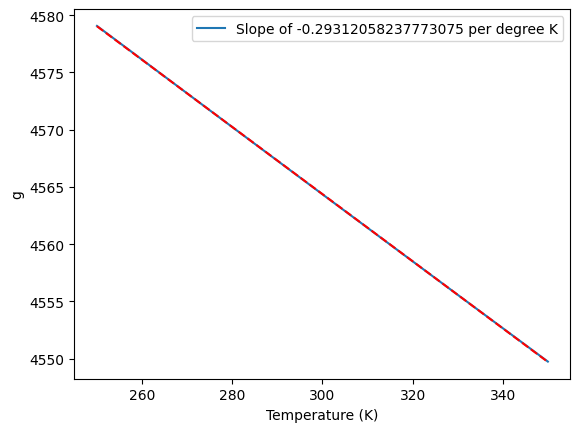

In [ ]:
lam = 1550e-9
L_0 = 250e-6
alpha_s = 0.0
n_room_temp = 3.60 # refractive index, at room temperature I think
n_0 = n_room_temp
dn_dT = 2e-4 # K^-1
linear_thermal_expansion = 5.6e-6 # K^-1
alpha_L = linear_thermal_expansion
E_go = 0.850 # eV
A = 4.906e-4 # eV
B = 301 # K

import matplotlib.pyplot as plt

# print( 
#     (4*dn_dT * ((n_room_temp-1)**4 - (n_room_temp+1)**4)/((n_room_temp+1)*(n_room_temp-1)) - np.log((n_room_temp+1)**4/(n_room_temp-1)**4)*linear_thermal_expansion)/(2*L)
# )


dg_dT = (1/(2*L_0)) * (n_room_temp - 1)**4 / (n_room_temp + 1)**4 * ((n_room_temp-1)**4 * 4*(n_room_temp+1)**3 * dn_dT - (n_room_temp+1)**4 * 4*(n_room_temp-1)**3 * dn_dT)/(n_room_temp-1)**8 -linear_thermal_expansion*np.log((n_room_temp+1)**4 / (n_room_temp - 1)**4) / (2*L_0)

dg_dT = 2*dn_dT / L_0 * ((n_0 - 1)-(n_0 + 1))/((n_0 - 1)*(n_0 + 1)) - alpha_L / (2 * L_0)*np.log(((n_0 + 1)/(n_0 -1))**4)
print( 
    f"dg_dT = {dg_dT} K^-1"    
)

# print( 
#     (1/(2*L)) * (n_room_temp - 1)**4 / (n_room_temp + 1)**4 * ((n_room_temp-1)**4 * 4*(n_room_temp+1)**3 * dn_dT - (n_room_temp+1)**4 * 4*(n_room_temp-1)**3 * dn_dT)/(n_room_temp-1)**8
# )

# print(-linear_thermal_expansion*np.log((n_room_temp+1)**4 / (n_room_temp - 1)**4) / (2*L))

T = np.linspace(250, 350, 1000)
alpha_T = 5.6*10**-6
n = n_room_temp - dn_dT*(300 - T)
L = (1 + alpha_T * (T-300)) * L_0
# plt.plot(T, n)

R = (n-1)**2 / (n+1)**2 # Assuming that this is at 
# x = 1/R**2
# plt.plot(x, np.log(1/R**2))
# plt.plot(x, 0.104*x + 1.26)

# plt.show()
g = 1/(2*L) * np.log(1/R**2)

slope, intercept = np.polyfit(T, g, deg=1)

plt.plot(T, g, label=f"Slope of {slope} per degree K")
plt.plot(T, T*slope+intercept, "r--")
plt.xlabel("Temperature (K)")
plt.ylabel("g")
plt.legend()
plt.show()



Next, we must find how emission wavelength for a given mode changes per unit temperature change.

for a given mode the emission frequency is
$$ \nu_m = \frac{mc}{2nL} $$
Where m is an integer indicating the mode number
$$ \lambda_m = \frac{c}{\nu_m} = \frac{2nL}{m} $$
$$ \frac{d\lambda_m}{dT} = \frac{d}{dT}[\frac{2nL}{m}] $$

$$ \frac{d\lambda_m}{dT} = \frac{d}{dT}[\frac{2(n_0 + \frac{dn}{dT}\Delta T)(L_{0}( 1 + \alpha_L \Delta T))}{m}] $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}\frac{d}{dT}[(n_0 + \frac{dn}{dT}\Delta T)(L_{0}( 1 + \alpha_L \Delta T))] $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}[(n_0 + \frac{dn}{dT}\Delta T)\frac{d}{dT}[L_{0}( 1 + \alpha_L \Delta T)] + \frac{d}{dT}[n_0 + \frac{dn}{dT}\Delta T](L_{0}( 1 + \alpha_L \Delta T))] $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}(n_0\frac{d}{dT}[L_{0}( 1 + \alpha_L (T-300))] + L_{0}\frac{d}{dT}[n_0 + \frac{dn}{dT}(T-300)]) $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}(n_0L_{0}\alpha_L + L_{0}\frac{dn}{dT}) $$

$$ \frac{d\lambda_m}{dT} = \frac{2L_{0}}{m}(n_0\alpha_L + \frac{dn}{dT}) $$

1.1007999999999938e-13
1.1008000000000001e-13


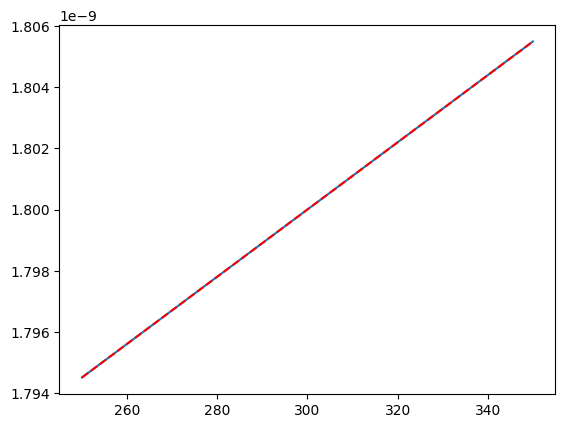

In [13]:
m = 1e6

lam = 2*n*L / m

slope, intercept = np.polyfit(T, lam, deg=1)
plt.plot(T, lam)
plt.plot(T, slope*T + intercept, "r--")

print(slope)
dlam_m_dT = 2*L_0/m*(n_0*alpha_L + dn_dT)
print(dlam_m_dT)

Without reference to the specific mode number we continue
$$ \lambda = \frac{c}{\nu} $$

We can rewrite $\nu$ in terms of the bandgap  

$$ \nu = \frac{E_g}{h} $$
$$ \lambda = \frac{hc}{E_g} = \frac{hc}{E_{go} - AT^2/(B+T)}$$

Taking the derivative  
$$ \frac{d\lambda}{dT} = -\frac{hc}{(qE_{go} - qAT^2/(B+T))^2 }\times \frac{q2AT(B+T) - qAT^2}{(B+T)^2}$$
$$ \frac{d\lambda}{dT} = -\frac{hc}{q(E_{go} - AT^2/(B+T))^2 }\times \frac{2ATB+AT^2}{(B+T)^2}$$
$$ \frac{d\lambda}{dT} = -\frac{hc}{q(E_{go} - AT^2/(B+T))^2 }\times  \frac{2ATB+AT^2}{(B+T)^2}$$

7.555041880985263e-10
-7.557071261468189e-10


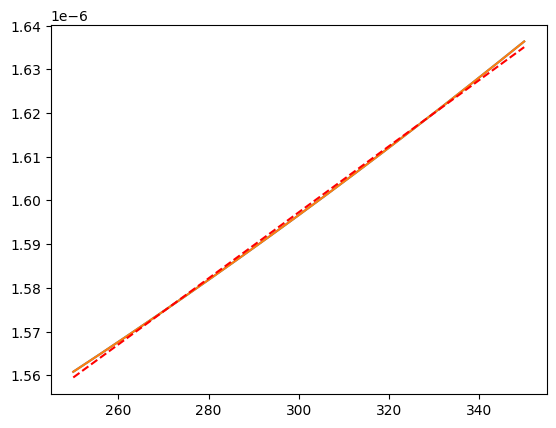

In [24]:
E_g = e*(E_go - A*T**2 / (B+T))
f = (E_g) / h
lam = c / f

slope, intercept = np.polyfit(T, lam, deg=1)
plt.plot(T, lam)
plt.plot(T, h*c/E_g)
plt.plot(T, slope*T + intercept, "r--")

print(slope)
print(- h*c/(e*(E_go - A*300**2/(B+300))**2) * (2*A*300*B + A*300**2)/(B+300)**2)

Clearly, the optical gain curve shifts by -0.29 per degree kelvin.

Clearly, the change in wavelength due to the change in bandgap dominates the change in the wavelength of an individual mode number.

# 4.31

# 4.42

# 7.3

